In [ ]:
!pip install yfinance

# use your mobile data to install yfiannce

In [74]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8")


In [75]:
start_date = "2025-02-04"
end_date = "2026-02-04"

hdfc = yf.download("HDFCBANK.NS", start=start_date, end=end_date)['Close']
sparc = yf.download("SPARC.NS", start=start_date, end=end_date)['Close']

df = pd.concat([hdfc, sparc], axis=1)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [76]:
df.to_csv("HDFC_SPARC_Closing_Prices.csv", index=True)

In [77]:
df.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,247.000000,247.000000
mean,952.320942,143.834899
std,51.399733,13.444033
min,827.366516,112.010002
25%,937.149994,133.570000
50%,965.250000,142.610001
75%,992.140472,152.639999
max,1012.900024,198.539993


<Figure size 1000x600 with 0 Axes>

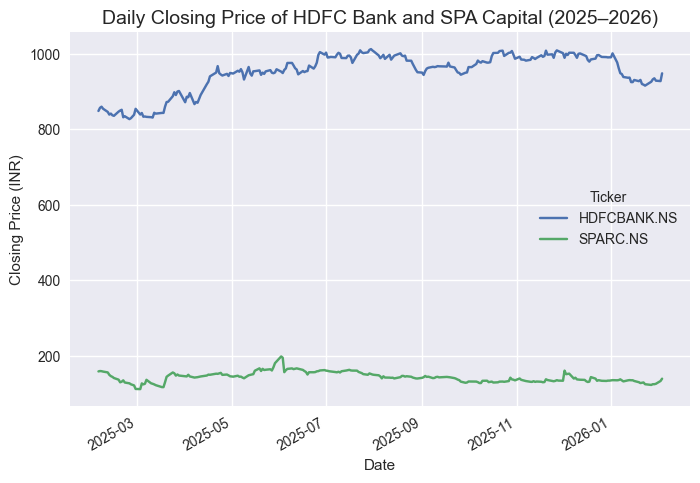

<Figure size 800x550 with 0 Axes>

In [78]:
plt.figure(figsize=(10,6))

df.plot()

plt.title("Daily Closing Price of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid(True)

plt.show()
plt.savefig('daily_closing_price_of_HDFC_Bank_and_SPA_Capital.png')


In [79]:
returns = df.pct_change()
returns.head()

Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-02-04,NaN,NaN
2025-02-05,0.009820,0.006169
2025-02-06,0.003481,-0.002440
2025-02-07,-0.006365,-0.006397
2025-02-10,-0.009811,-0.014076


In [80]:
returns = returns.dropna()
returns.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,246.000000,246.000000
mean,0.000496,0.000002
std,0.009499,0.032697
min,-0.033011,-0.196485
25%,-0.005037,-0.015058
50%,0.000228,-0.002708
75%,0.006190,0.007827
max,0.035720,0.199940


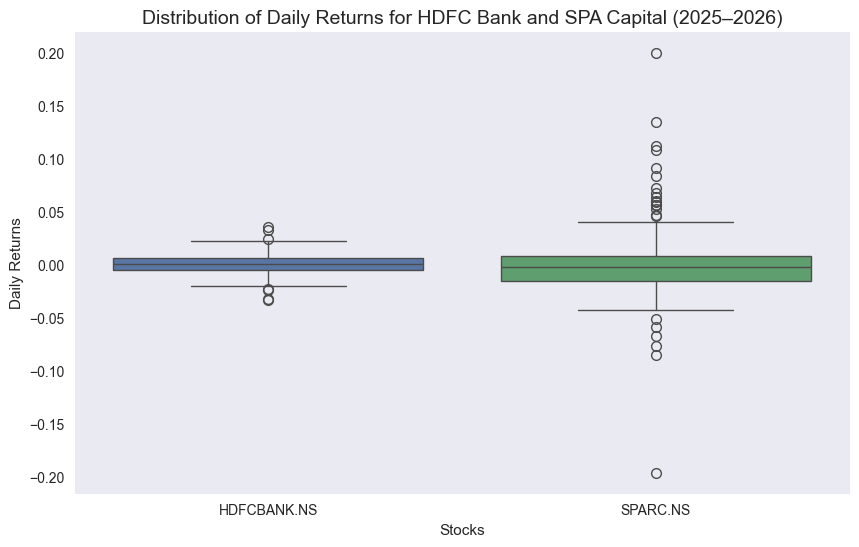

In [81]:
plt.figure(figsize=(10,6))

sns.boxplot(data=returns)

plt.title("Distribution of Daily Returns for HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.xlabel("Stocks")
plt.ylabel("Daily Returns")
plt.grid(axis='y')

plt.show()

<Figure size 1000x600 with 0 Axes>

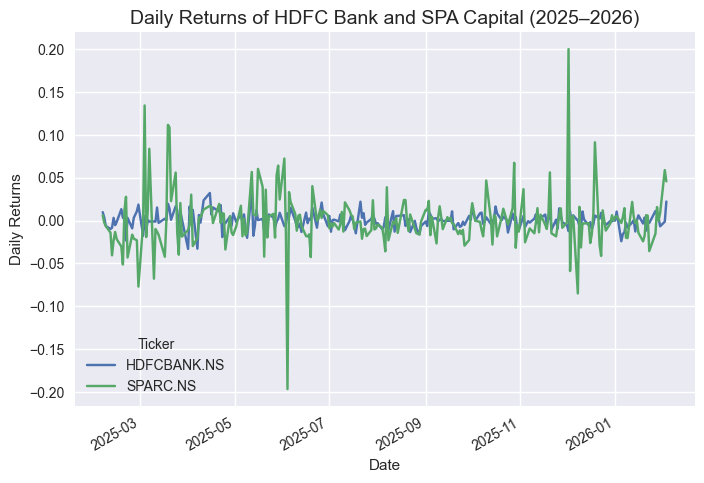

In [82]:
plt.figure(figsize=(10,6))
returns.plot()
plt.title("Daily Returns of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.ylabel("Daily Returns")
plt.xlabel("Date")
plt.grid(True)
plt.show()


### Compounding Returns

In [83]:
Compounded_returns = (((returns+1).prod()-1)*100).round(2)
Compounded_returns

Ticker
HDFCBANK.NS    11.75
SPARC.NS      -12.12
dtype: float64

### Annualized Returns

In [84]:
annualized_return = Compounded_returns

### Annualized Volatility (Converting volatility for a daily series to yearly)

In [85]:
annualized_vol = returns.std() * (returns.shape[1] ** 0.5)
annualized_vol

Ticker
HDFCBANK.NS    0.013433
SPARC.NS       0.046240
dtype: float64

### Skewness

In [86]:
skewness = returns.skew()
skewness

Ticker
HDFCBANK.NS    0.025103
SPARC.NS       0.793967
dtype: float64

### Kurtosis

In [87]:
kurtosis = returns.kurt()
kurtosis

Ticker
HDFCBANK.NS     1.654554
SPARC.NS       12.133483
dtype: float64

### Return Risk Ratio


In [88]:
return_risk_ratio = annualized_return / annualized_vol
return_risk_ratio


Ticker
HDFCBANK.NS    874.685221
SPARC.NS      -262.110461
dtype: float64

### Maximum Drawdown and Wealth Index

In [89]:
wealth_index = (1 + returns).cumprod()
wealth_index.head()


Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-02-05,1.009820,1.006169
2025-02-06,1.013336,1.003714
2025-02-07,1.006886,0.997293
2025-02-10,0.997007,0.983256
2025-02-11,0.988669,0.943409


<Figure size 1000x600 with 0 Axes>

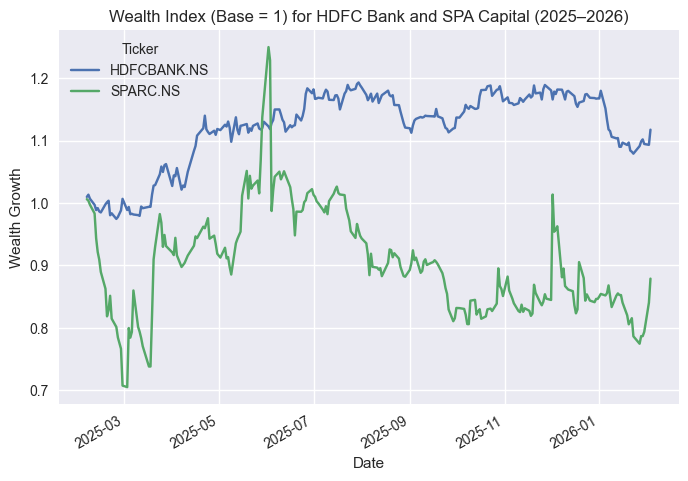

In [90]:
plt.figure(figsize=(10,6))

wealth_index.plot()

plt.title("Wealth Index (Base = 1) for HDFC Bank and SPA Capital (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Wealth Growth")
plt.grid(True)

plt.show()


In [91]:
running_max = wealth_index.cummax()


In [92]:
drawdown = wealth_index / running_max - 1

In [93]:
max_drawdown = drawdown.min()
max_drawdown


Ticker
HDFCBANK.NS   -0.095567
SPARC.NS      -0.380226
dtype: float64

### Interpretation of Analysis Results

**1. Daily Closing Prices Plot (HDFC Bank and SPA Capital)**
*   The plot shows the closing price movement of both stocks over the period. HDFC Bank (blue line) appears to fluctuate within a narrower range, while SPA Capital (orange line) exhibits more prominent price swings, especially a significant dip towards the end of the period.

**2. Descriptive Statistics of Daily Returns (`returns.describe()`)**
*   **HDFCBANK.NS:**
    *   **Mean:** The average daily return is approximately 0.000496 (0.0496%), indicating a slightly positive average daily return. This is quite low for daily returns and suggests stability.
    *   **Standard Deviation (Volatility):** 0.009499. This is a measure of the dispersion of returns around the mean. A lower standard deviation indicates less volatility.
    *   **Min/Max:** Returns range from -3.30% to 3.57%, showing its daily fluctuations.
*   **SPARC.NS:**
    *   **Mean:** The average daily return is approximately 0.000002 (0.0002%), which is almost flat, suggesting that on average, the daily returns are close to zero over the period.
    *   **Standard Deviation (Volatility):** 0.032697. This is significantly higher than HDFC Bank, indicating much greater daily volatility.
    *   **Min/Max:** Returns range from -19.65% to 19.99%, highlighting very large daily price swings.

**3. Daily Returns Plot (HDFC Bank and SPA Capital)**
*   This plot visually confirms the higher volatility of SPA Capital. Its returns line shows much larger spikes and dips compared to the more contained fluctuations of HDFC Bank, especially notable are the extreme negative returns for SPARC around November 2025.

**4. Box Plot of Daily Returns (HDFC Bank and SPA Capital)**
*   The box plot provides a clear visual comparison of the distribution of daily returns.
    *   **HDFC Bank:** The box is much tighter, indicating less spread in returns. The whiskers are shorter, and there are fewer outliers, confirming lower volatility.
    *   **SPA Capital:** The box is much wider, and the whiskers are significantly longer, with numerous outliers, especially on the negative side. This signifies a much higher degree of volatility and more extreme daily price movements compared to HDFC Bank.

**5. Compounded Returns**
*   **HDFCBANK.NS:** 11.75%
*   **SPARC.NS:** -12.12%
    *   Over the entire period, HDFC Bank generated a positive compounded return of 11.75%, while SPA Capital had a negative compounded return of -12.12%. This indicates that an investment in HDFC Bank would have grown, whereas an investment in SPA Capital would have declined.

**6. Annualized Volatility**
*   **HDFCBANK.NS:** 0.013433
*   **SPARC.NS:** 0.046240
    *   The annualized volatility confirms that SPA Capital is significantly more volatile than HDFC Bank. This metric translates the daily volatility into an annual figure, making the risk comparison more intuitive over a longer horizon.

**7. Skewness**
*   **HDFCBANK.NS:** 0.025103 (close to 0, slightly positive)
*   **SPARC.NS:** 0.793967 (positive)
    *   **HDFC Bank's** returns distribution is nearly symmetrical (slightly positively skewed), meaning large positive and negative returns are somewhat balanced.
    *   **SPA Capital's** returns are positively skewed, indicating a longer or fatter tail on the right side of the distribution. This suggests that large positive returns are more frequent or larger in magnitude than large negative returns, despite the overall negative compounded return. However, it also has a significant number of negative outliers as seen in the box plot.

**8. Kurtosis**
*   **HDFCBANK.NS:** 1.654554 (less than 3, platykurtic)
*   **SPARC.NS:** 12.133483 (much greater than 3, leptokurtic)
    *   **HDFC Bank's** returns distribution is platykurtic, meaning it has lighter tails and fewer extreme outliers than a normal distribution. This is another indicator of lower risk.
    *   **SPA Capital's** returns distribution is highly leptokurtic, meaning it has fatter tails and a higher peak than a normal distribution. This indicates a higher probability of extreme price movements (both positive and negative), consistent with its high volatility and wide range of returns.

**9. Return Risk Ratio**
*   **HDFCBANK.NS:** 874.685221
*   **SPARC.NS:** -262.110461
    *   This ratio (often related to the Sharpe ratio when excess return over a risk-free rate is used) measures the return generated per unit of risk. HDFC Bank has a very high positive return-risk ratio, suggesting it generated a significant return for its level of volatility. SPA Capital has a negative ratio due to its negative overall return, indicating that its high volatility did not translate into positive returns.

**10. Wealth Index Plot**
*   The wealth index, starting at 1, shows how an initial investment would have grown or shrunk over time. HDFC Bank's wealth index steadily increased, reflecting its positive compounded returns. In contrast, SPA Capital's wealth index shows a significant decline, especially from late 2025, which corresponds to its negative compounded returns and periods of high negative daily returns.

**11. Maximum Drawdown**
*   **HDFCBANK.NS:** -0.095567 (-9.56%)
*   **SPARC.NS:** -0.380226 (-38.02%)
    *   The maximum drawdown represents the largest peak-to-trough decline in the wealth index. HDFC Bank experienced a maximum drawdown of about 9.56%, meaning at its worst, an investment in HDFC Bank lost this much value from a previous peak. SPA Capital, on the other hand, suffered a much larger maximum drawdown of approximately 38.02%, highlighting a significantly higher downside risk during the observed period.